In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO


In [2]:
data_dir = "/kaggle/input/coco-2017-dataset/coco2017"
img_dir = os.path.join(data_dir, "train2017")
ann_file = os.path.join(data_dir, "annotations", "instances_train2017.json")

# Load COCO annotations
coco = COCO(ann_file)
img_ids = coco.getImgIds()
img_ids = img_ids[:5] 

images = []
gt_masks = []

for img_id in img_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    img = cv2.imread(img_path)
    images.append(img)

    ann_ids = coco.getAnnIds(imgIds=img_id, iscrowd=False)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
    for ann in anns:
        mask |= coco.annToMask(ann)
    gt_masks.append(mask)


loading annotations into memory...
Done (t=22.19s)
creating index...
index created!


In [3]:
def add_noise(mask, noise_level=0.05):
    noisy = mask.copy()
    h, w = noisy.shape
    num_pixels = int(noise_level * h * w)
    for _ in range(num_pixels):
        x, y = np.random.randint(0, w), np.random.randint(0, h)
        noisy[y, x] = 1 - noisy[y, x]
    return (noisy * 255).astype(np.uint8)

masks_pred = [add_noise(m) for m in gt_masks]

In [4]:
def postprocess_mask(mask):
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    smooth = np.zeros_like(mask)
    cv2.drawContours(smooth, contours, -1, 255, thickness=cv2.FILLED)
    return binary, smooth

In [5]:
def show_masks(img, raw_mask, processed_mask):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Original Image")
    axs[1].imshow(raw_mask, cmap='gray')
    axs[1].set_title("Noisy Predicted Mask")
    axs[2].imshow(processed_mask, cmap='gray')
    axs[2].set_title("Post-Processed Mask")
    for ax in axs: ax.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
def visualize_errors(gt_mask, pred_mask, image):
    gt_bin = (gt_mask > 127).astype(np.uint8)
    pred_bin = (pred_mask > 127).astype(np.uint8)

    fp = (pred_bin == 1) & (gt_bin == 0)
    fn = (pred_bin == 0) & (gt_bin == 1)

    overlay = image.copy()
    overlay[fp] = [255, 0, 0]   # FP - Blue
    overlay[fn] = [0, 0, 255]   # FN - Red

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Error Overlay: FP (Blue), FN (Red)")
    plt.axis('off')
    plt.show()

- Original Image: A person riding a motorcycle on a dirt path, captured in a natural outdoor scene.
- Noisy Predicted Mask: Initial segmentation with scattered white noise and incomplete object boundaries.
- Post-Processed Mask: Cleaned mask showing a well-defined silhouette of the person and motorcycle.
- Error Overlay (FP Blue, FN Red): Visual comparison of FP and FN missed object regions (red) and over-segmented areas (blue).


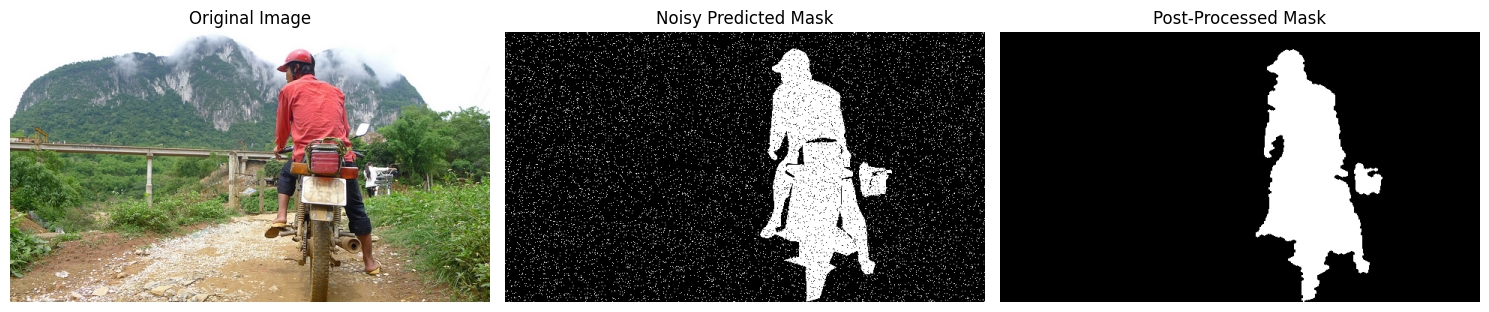

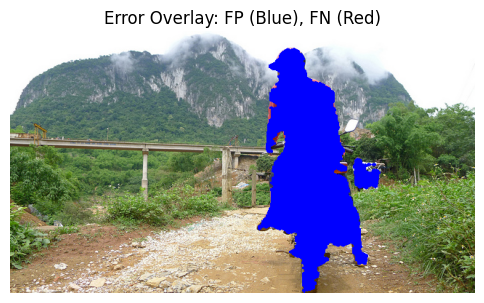

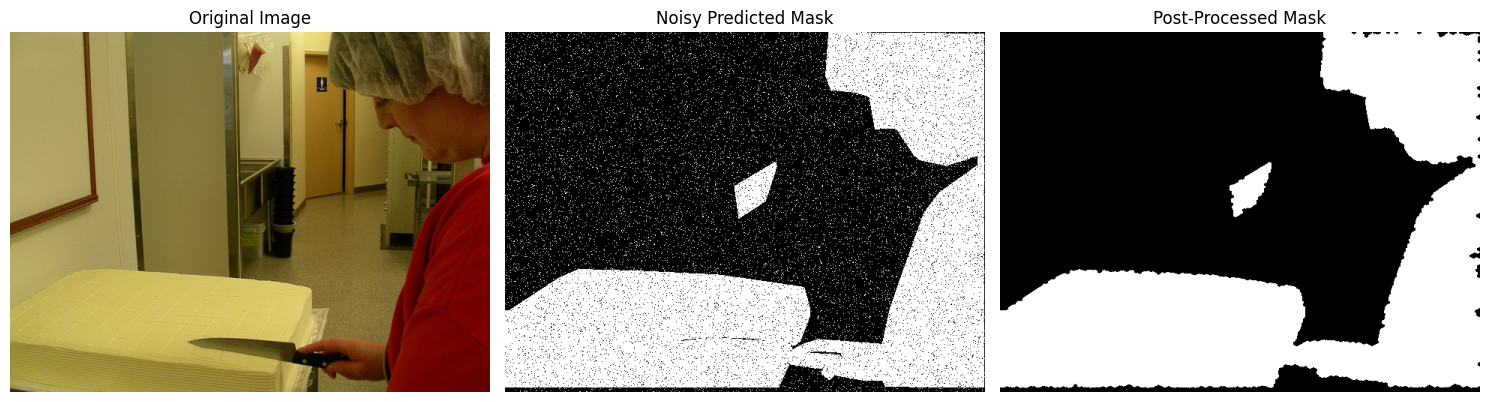

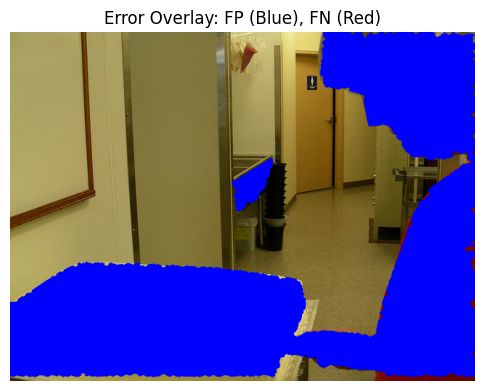

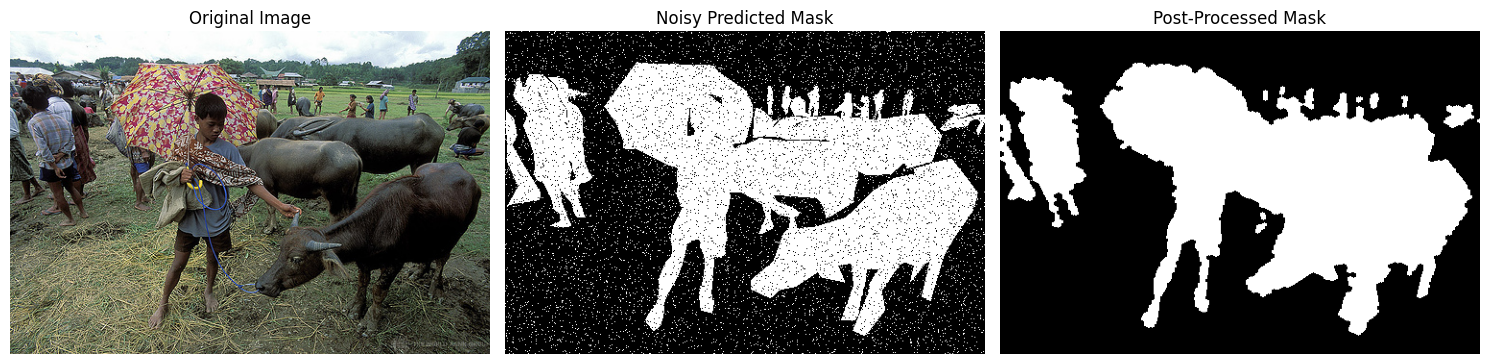

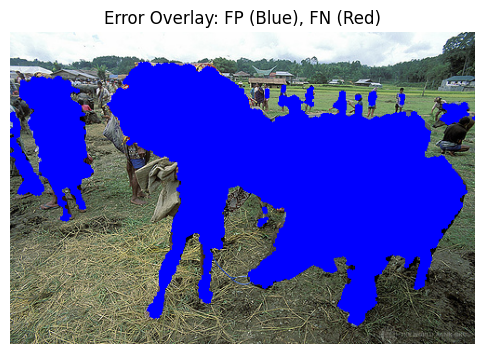

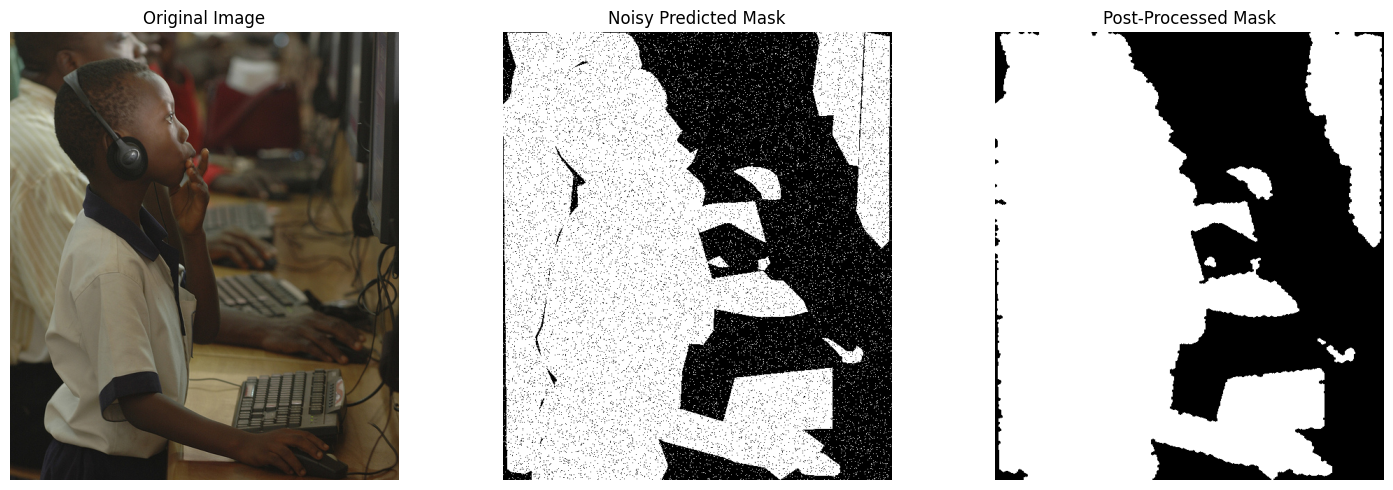

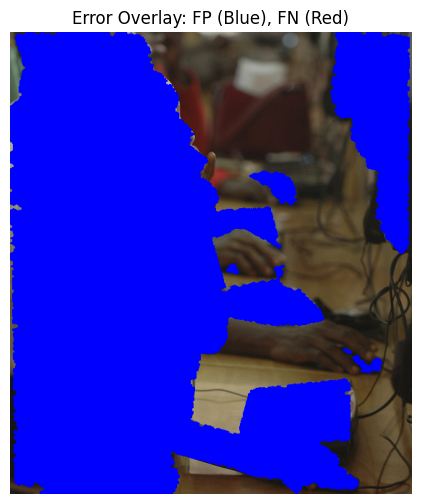

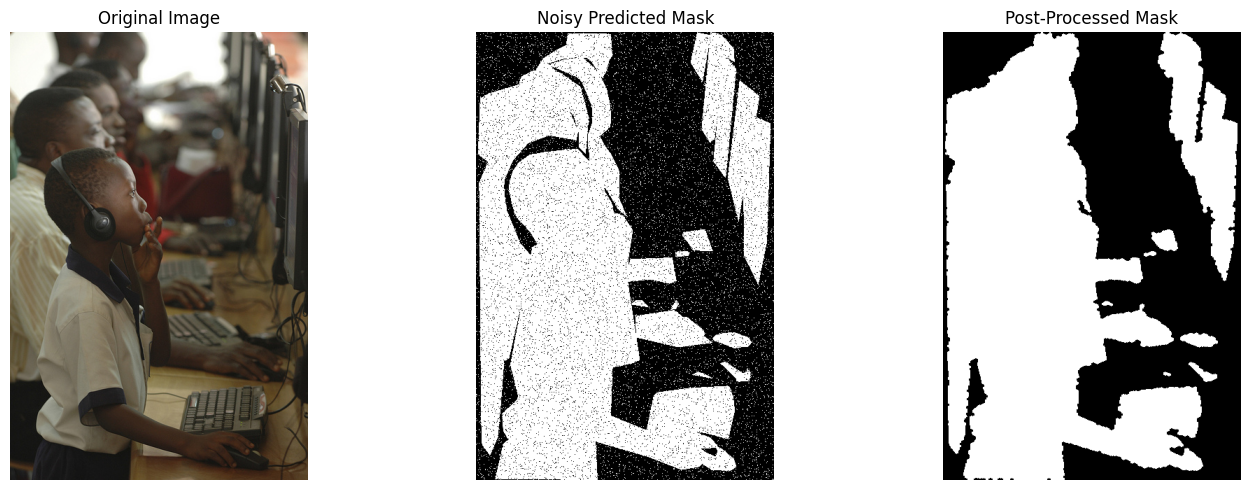

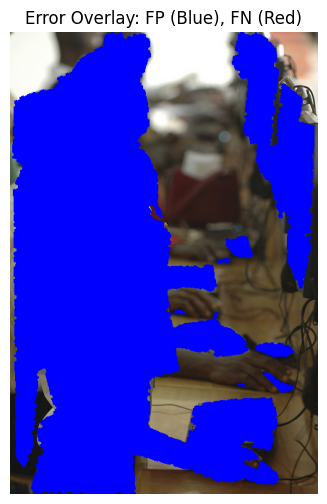

In [7]:
for i in range(5):
    img = images[i]
    raw_mask = masks_pred[i]
    gt_mask = gt_masks[i]
    binary, processed = postprocess_mask(raw_mask)
    show_masks(img, raw_mask, processed)
    visualize_errors(gt_mask, processed, img)